In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


# Explicacion

Este caso se intentó hacer antes de evaluar los contenidos de la clase 5. La logica que se buscó fue:

1. Reescalar la imagen del logo para que siempre sea mas pequeña que la imagen a detectar
2. Utilizar canny, para quitar influencia de colores, fondos, etc, del logo
3. De forma iterativa, ir intentando detectar elementos en la imagen, hasta que la imagen a detectar sea del tamaño del logo

Esto unicamente nos funcionó en un caso, pero lo dejamos como muestra de la logica que intentamos aplicar

In [3]:
img_path = "images/coca_logo_1.png"

template_path = "template/pattern.png"

In [39]:
def detection_function(img_path:str, template_path:str, resize_percentaje, threshold):
    # Procesamos template

    template_img = cv.imread(template_path,0)
    template_edges = cv.Canny(template_img,100,200)


    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(template_img, cmap='gray')
    plt.subplot(1,2,2)
    plt.imshow(template_edges)
    plt.show()

    img_grayscale = cv.imread(img_path,0)
    image_edges = cv.Canny(img_grayscale,100,200)

    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(img_grayscale, cmap='gray')
    plt.subplot(1,2,2)
    plt.imshow(image_edges)
    plt.show()

    max_dim = np.argmax(template_edges.shape)

    scale_factor = ((img_grayscale.shape[max_dim]*resize_percentaje/100)/template_edges.shape[max_dim])

    # Resize the image (scaling down)
    resized_down_template = cv.resize(template_edges, None, fx=scale_factor, fy=scale_factor, interpolation=cv.INTER_AREA)


    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(template_edges, cmap='gray')
    plt.title("Template original")
    plt.subplot(1,2,2)
    plt.imshow(resized_down_template, cmap= 'gray')
    plt.title("Template reescalado")
    plt.show()
 
    current_image = image_edges.copy()

    edges = resized_down_template.copy()

    while (current_image.shape[0] > edges.shape[0]) and (current_image.shape[1] > edges.shape[1]):

        img_show = current_image.copy()

        method = eval('cv.TM_CCOEFF_NORMED')


        #current_edges = cv.Canny(current_image,100,200)

        res = cv.matchTemplate(current_image, edges, method)

        # Encontramos los valores máximos y mínimos
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

        w, h = edges.shape[::-1]

        threshold = 0.4

        loc = np.where( res >= threshold)
        for pt in zip(*loc[::-1]):
            cv.rectangle(img_show, pt, (pt[0] + w, pt[1] + h), (255,255,255), 2)

        if np.max(res) > threshold:
            print(f"Valor de confianza de deteccion: {np.max(res)}")

        # Graficamos el procesamiento y la salida
        #----------------------------------------
        plt.figure(figsize=(15, 5))
        # Resultado de coincidencia
        plt.subplot(121),plt.imshow(res,cmap = 'gray')
        plt.title('Matching Result'), plt.xticks([]), plt.yticks([])

        # Imagen original con recuadros
        plt.subplot(122),plt.imshow(img_show, cmap='gray')
        plt.title('Detected Point'), plt.xticks([]), plt.yticks([])

        #plt.subplot(133),plt.imshow(current_edges,cmap='grey')
        #plt.title('Detected Point'), plt.xticks([]), plt.yticks([])

        plt.suptitle(method)
        plt.show()
        
        print(current_image.shape)
        current_image = cv.resize(current_image, None, fx=0.80, fy=0.80, interpolation=cv.INTER_AREA).copy()
        #cv.imshow('Downscaled', current_image)
        #cv.waitKey(500)


In [11]:
resize_percentaje = 40

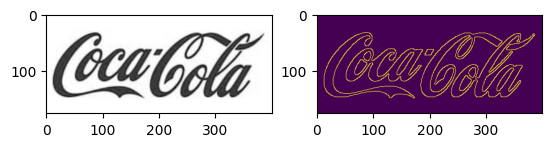

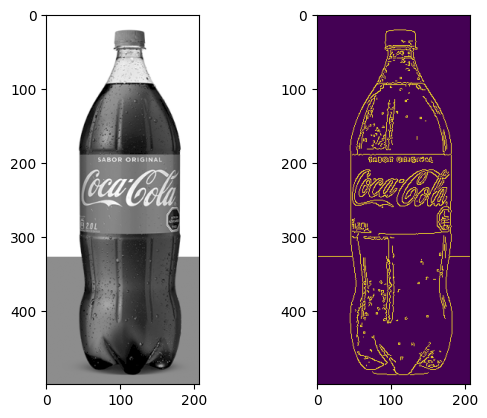

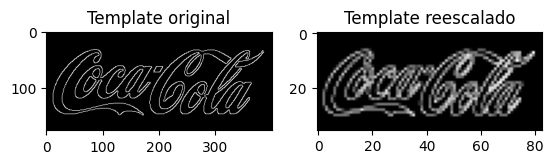

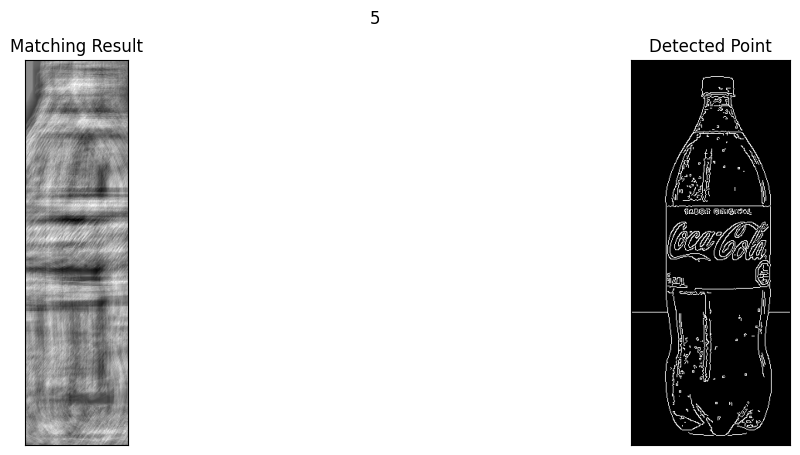

(500, 207)


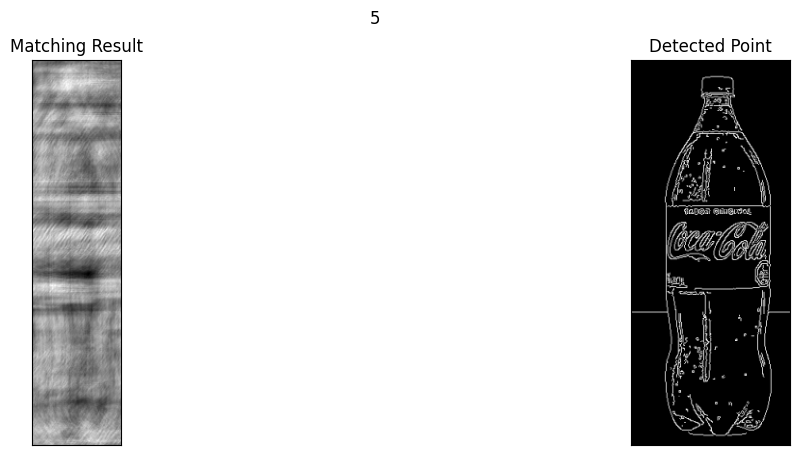

(400, 166)


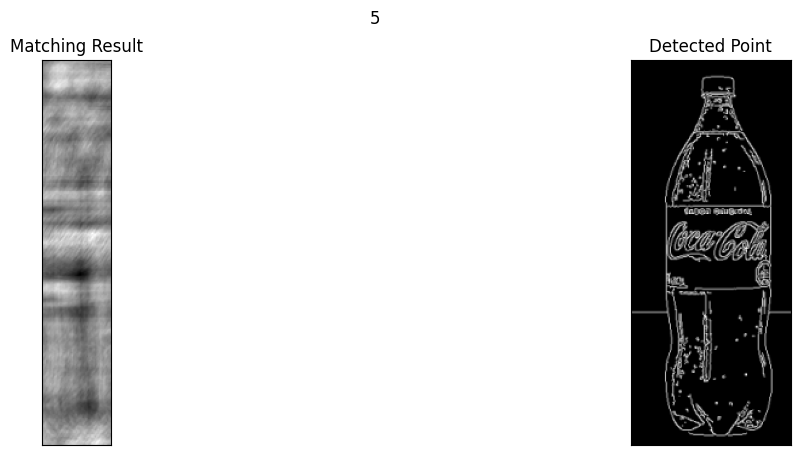

(320, 133)
Valor de confianza de deteccion: 0.510247528553009


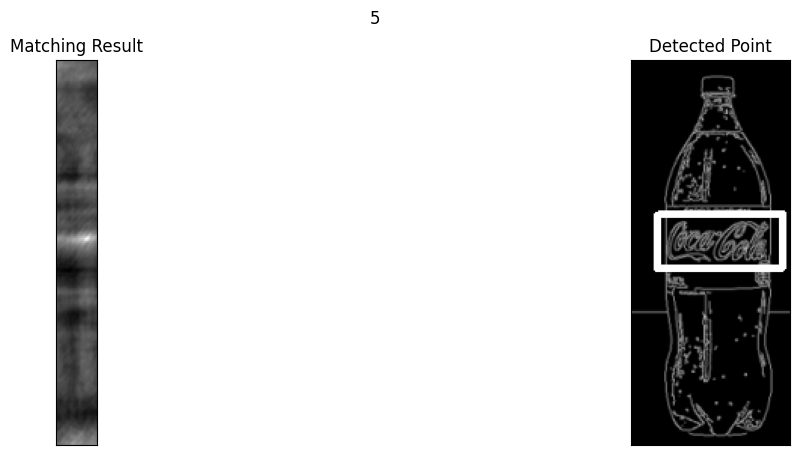

(256, 106)


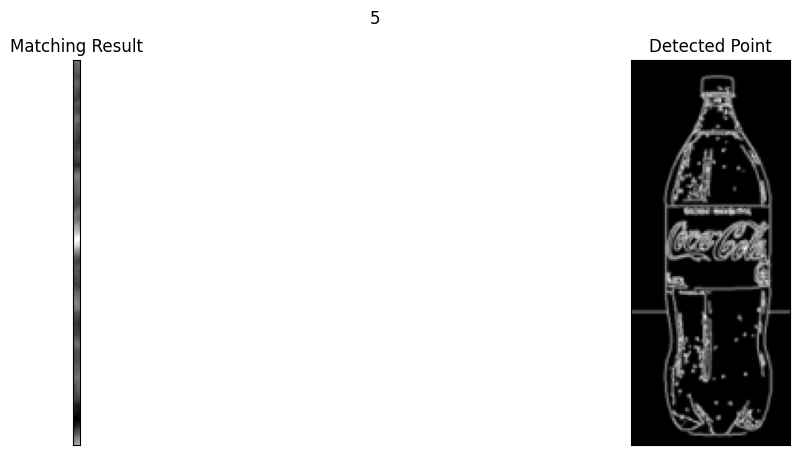

(205, 85)


In [40]:
detection_function(img_path=img_path, template_path=template_path, resize_percentaje=40, threshold=0.4)

Esto parece indicar resultados correctos, pero existe un problema. Si analizamos el valor de confianza encontramos que este es del 51%, no es muy alto. Si lo verificamos para otra imagen, tenemos:

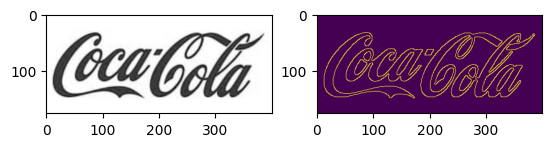

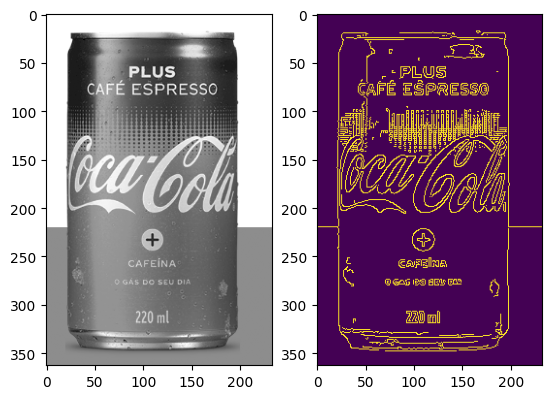

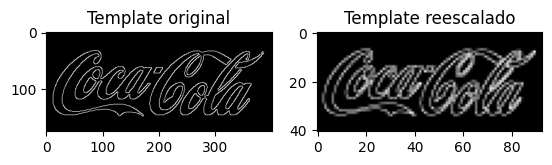

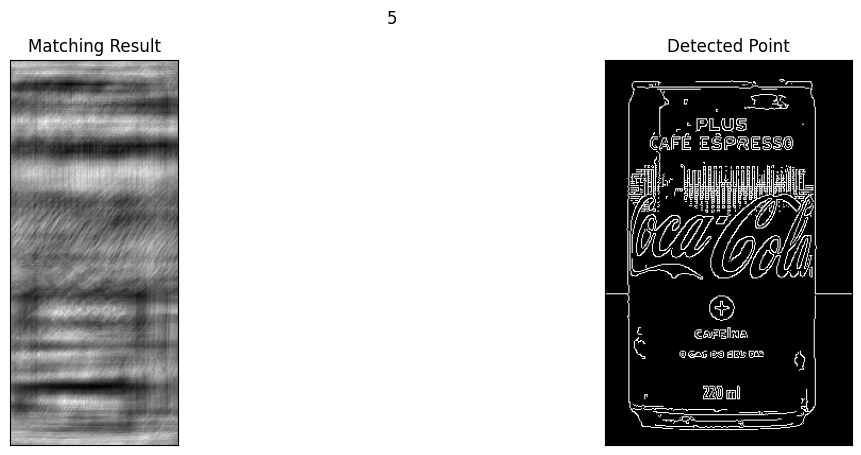

(363, 233)


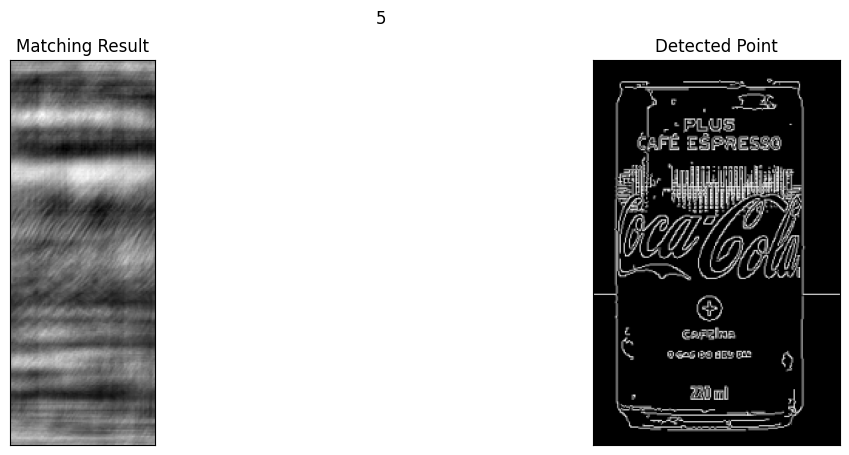

(290, 186)


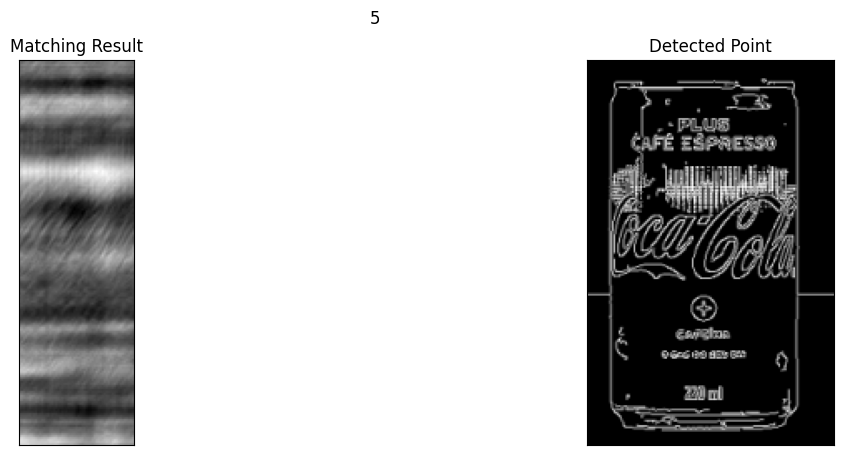

(232, 149)


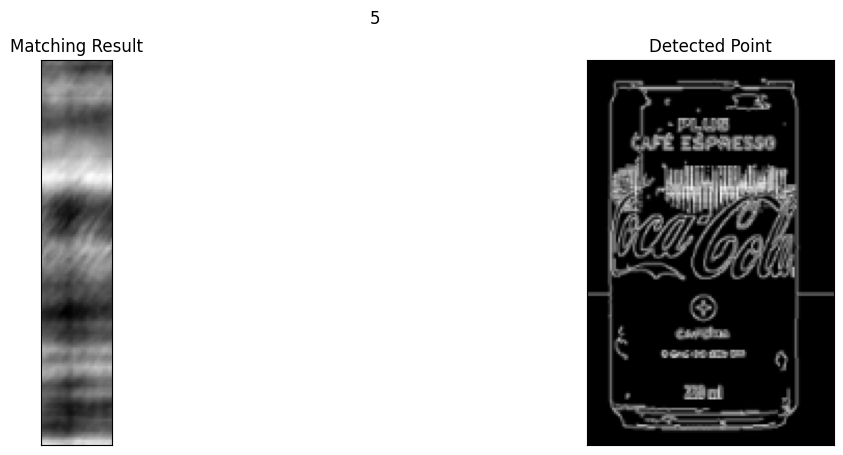

(186, 119)


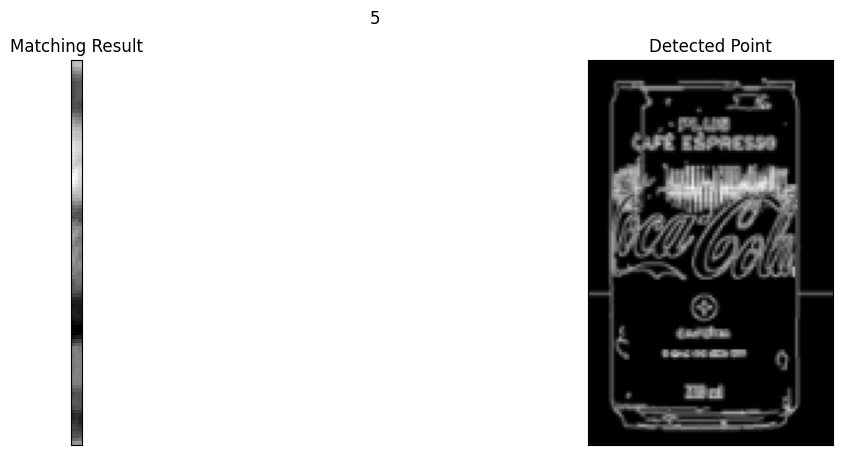

(149, 95)


In [41]:
detection_function(img_path="images/coca_logo_2.png", template_path=template_path, resize_percentaje=40, threshold=0.4)

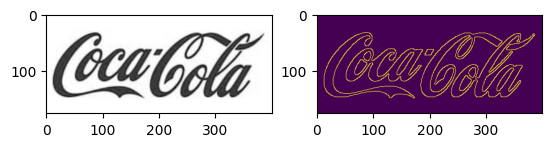

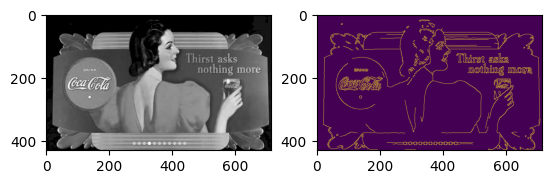

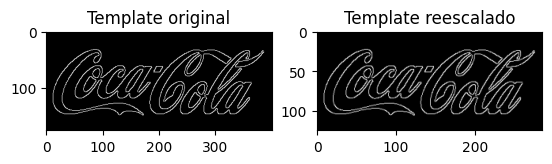

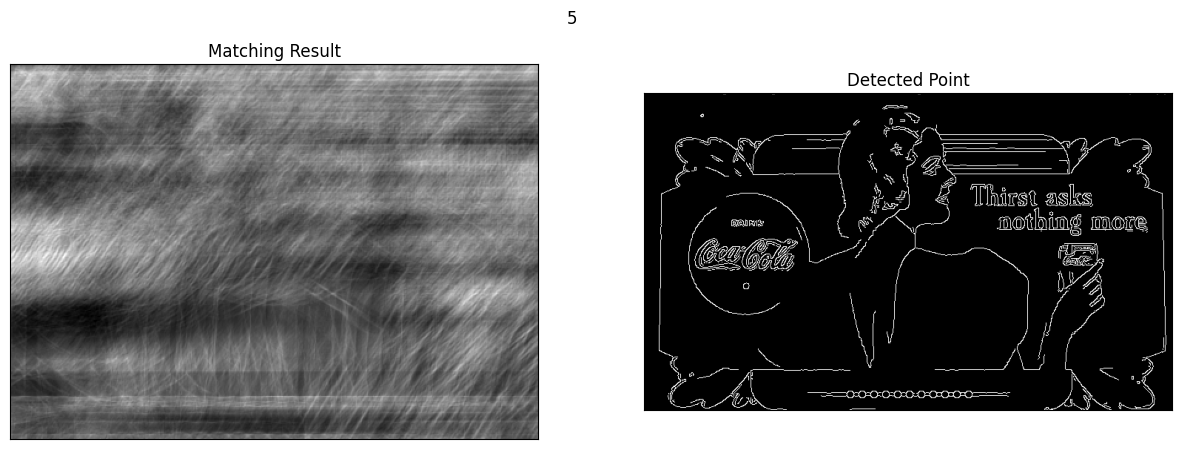

(429, 715)


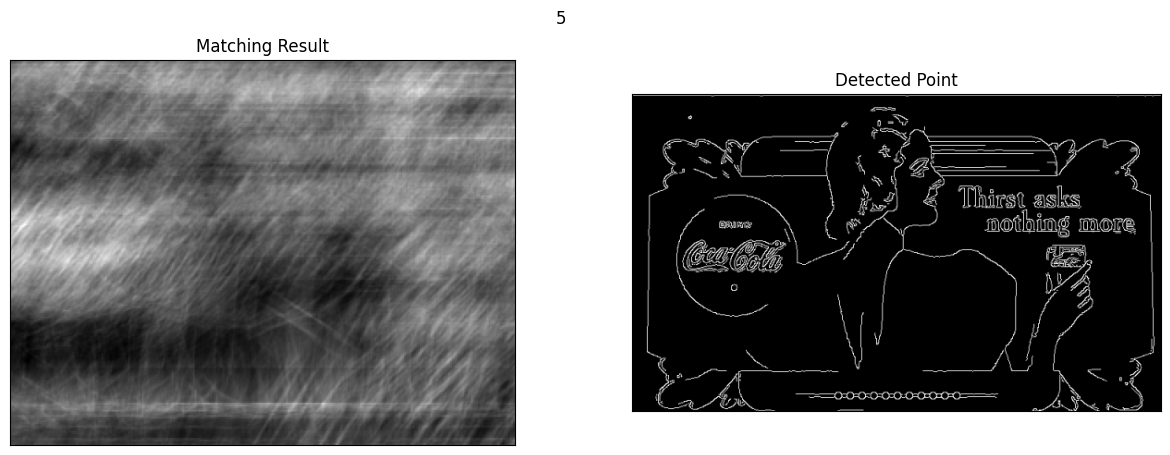

(343, 572)


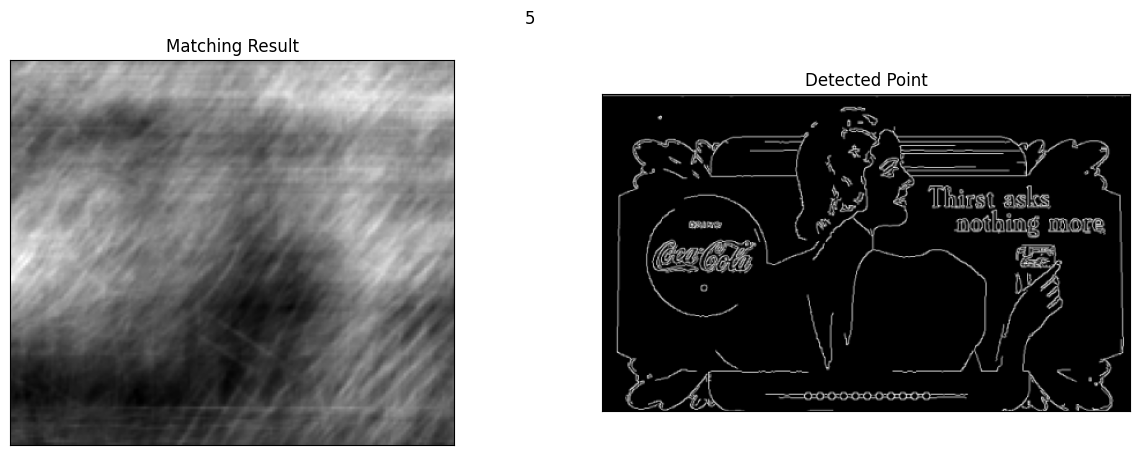

(274, 458)


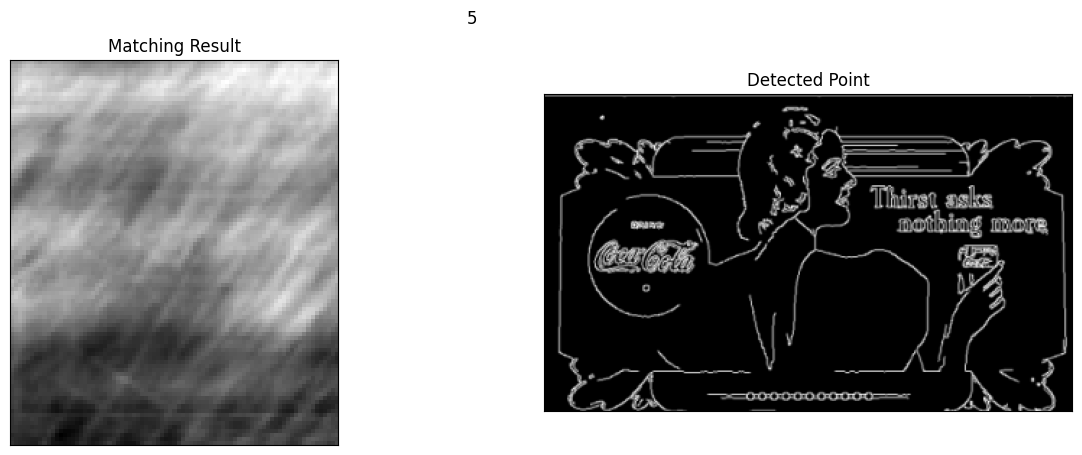

(219, 366)


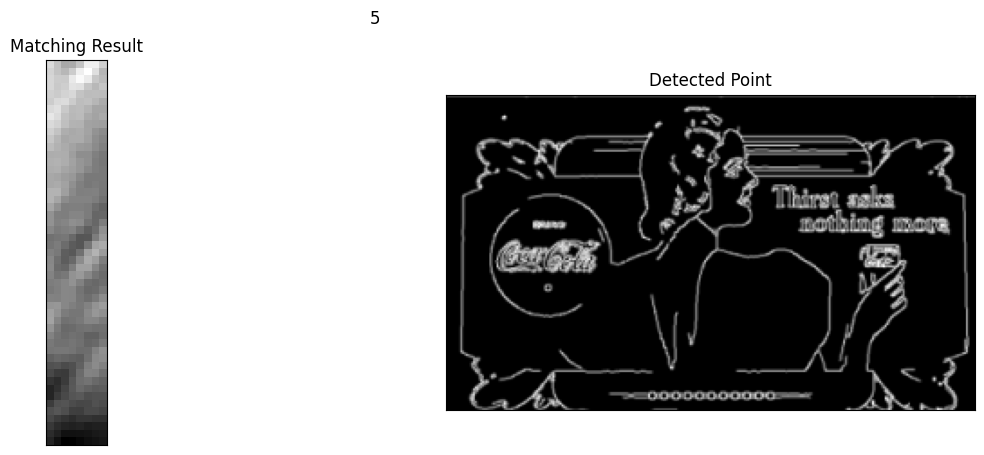

(175, 293)


In [42]:
detection_function(img_path="images/coca_retro_2.png", template_path=template_path, resize_percentaje=40, threshold=0.4)

Analizando los resultados, encontramos que si bien, la logica parecía prometedora, esta era muy poco robusta, ante cambios en la imagen, los resultados variaban de manera notable, lo que lo hacía un metodo muy poco fiable. Ante cambios en la imagen, debíamos modificar los parámetros de escalado y threshhold, lo cual no era ideal para una aplicación real.

In [3]:
img_path = "images/coca_logo_2.png"

template_path = "template/pattern.png"

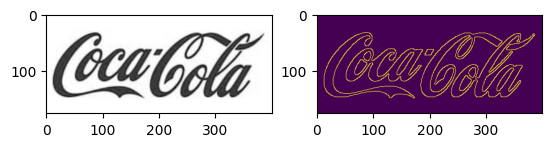

In [4]:
template_img = cv.imread(template_path,0)
template_edges = cv.Canny(template_img,100,200)


plt.figure()
plt.subplot(1,2,1)
plt.imshow(template_img, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(template_edges)
plt.show()

img_grayscale = cv.imread(img_path,0)
image_edges = cv.Canny(img_grayscale,100,200)

In [ ]:
import numpy as np
import cv2
 
    
# Read the query image as query_img
# and train image This query image
# is what you need to find in train image
# Save it in the same directory
# with the name image.jpg  
query_img = cv2.imread(template_path)
train_img = cv2.imread(img_path)
 
query_img = template_edges
train_img = image_edges

# Convert it to grayscale
#query_img_bw = cv2.cvtColor(query_img,cv2.COLOR_BGR2GRAY)
#train_img_bw = cv2.cvtColor(train_img, cv2.COLOR_BGR2GRAY)
 
# Initialize the ORB detector algorithm
orb = cv2.ORB_create()
 
# Now detect the keypoints and compute
# the descriptors for the query image
# and train image
queryKeypoints, queryDescriptors = orb.detectAndCompute(query_img,None)
trainKeypoints, trainDescriptors = orb.detectAndCompute(train_img,None)
0
# Initialize the Matcher for matching
# the keypoints and then match the
# keypoints
matcher = cv2.BFMatcher()
matches = matcher.match(queryDescriptors,trainDescriptors)
 
# draw the matches to the final image
# containing both the images the drawMatches()
# function takes both images and keypoints
# and outputs the matched query image with
# its train image
final_img = cv2.drawMatches(query_img, queryKeypoints, 
train_img, trainKeypoints, matches[:20],None)
 
final_img = cv2.resize(final_img, (1000,650))

# Show the final image
cv2.imshow("Matches", final_img)
cv2.waitKey(0)